In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df_sales = pd.read_csv('online_retail_sales_cleaned.csv')

In [4]:
df_sales.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,TotalPrice
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085,United Kingdom,83.4
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom,81.0
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom,81.0
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085,United Kingdom,100.8
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085,United Kingdom,30.0


In [5]:
df_sales['InvoiceDate'] = pd.to_datetime(df_sales['InvoiceDate'])

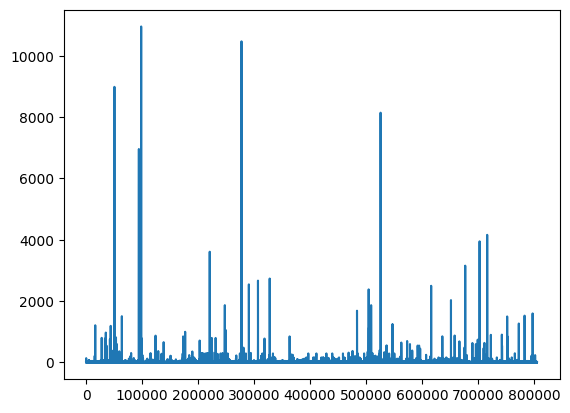

In [7]:
plt.plot(df_sales['Price'])
plt.show()

# Top Products By Revenue

In [12]:
top_products = df_sales.groupby('Description')['TotalPrice'].sum().sort_values(ascending=False).head(10)
top_products.head(10)

,TotalPrice
Description,
REGENCY CAKESTAND 3 TIER,286486.30
WHITE HANGING HEART T-LIGHT HOLDER,252072.46
"PAPER CRAFT , LITTLE BIRDIE",168469.60
Manual,152340.57
JUMBO BAG RED RETROSPOT,136980.08
ASSORTED COLOUR BIRD ORNAMENT,127074.17
POSTAGE,126563.04
PARTY BUNTING,103880.23
MEDIUM CERAMIC TOP STORAGE JAR,81416.73


In [13]:
top_customers = df_sales.groupby('Customer ID')['TotalPrice'].sum().sort_values(ascending=False).head(10)
top_customers

,TotalPrice
Customer ID,
18102,608821.65
14646,528602.52
14156,313946.37
14911,295972.63
17450,246973.09
13694,196482.81
17511,175603.55
16446,168472.50
16684,147142.77


In [14]:
df_sales['YearMonth'] = df_sales['InvoiceDate'].dt.to_period('M')
monthly_sales = df_sales.groupby('YearMonth')['TotalPrice'].sum()

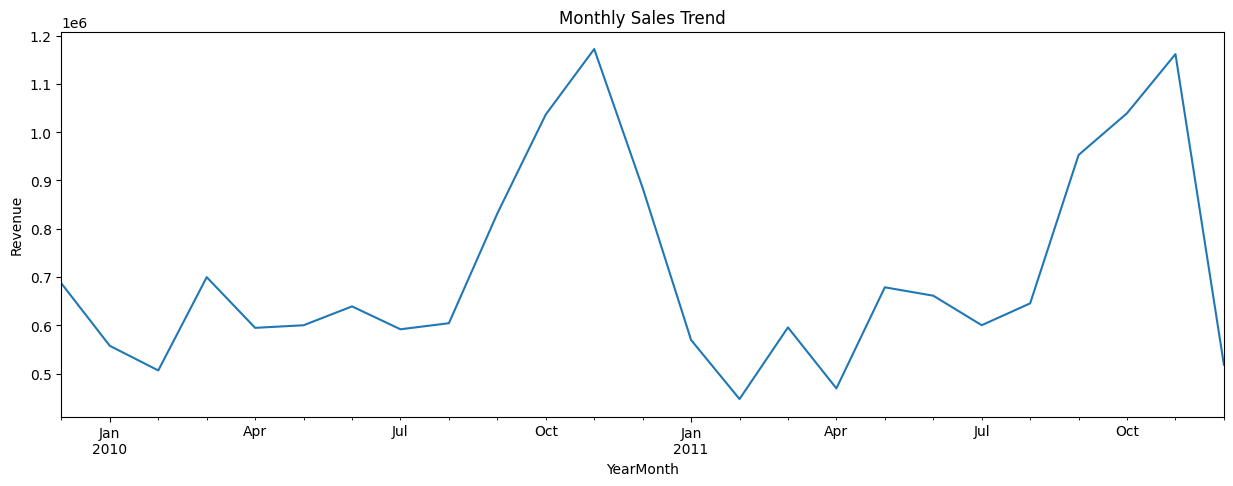

In [16]:
monthly_sales.plot(kind='line', figsize=(15,5), title='Monthly Sales Trend')
plt.ylabel('Revenue')
plt.show()

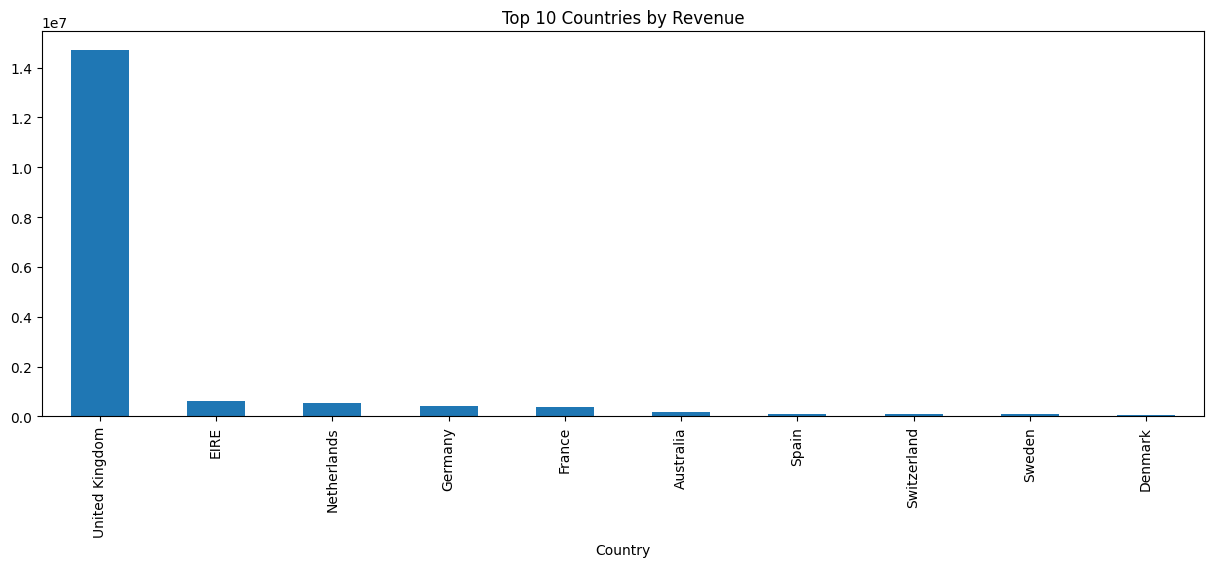

In [18]:
country_sales = df_sales.groupby('Country')['TotalPrice'].sum().sort_values(ascending=False).head(10)
country_sales.plot(kind='bar', figsize=(15,5), title='Top 10 Countries by Revenue')
plt.show()

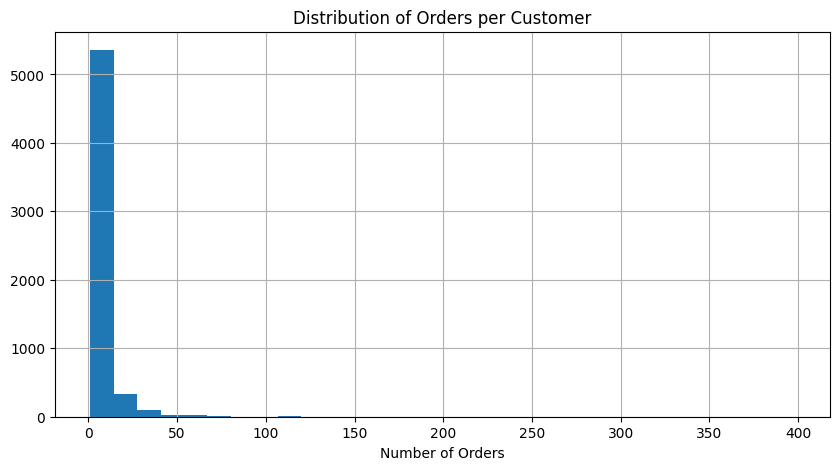

In [29]:
orders_per_customer = df_sales.groupby('Customer ID')['Invoice'].nunique()
orders_per_customer.hist(bins=30, figsize=(10,5))
plt.title('Distribution of Orders per Customer')
plt.xlabel('Number of Orders')
plt.show()